In [1]:
#Imports*
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os


In [3]:
#Load Validation Data
VAL_DIR = "../data/raw/val"

val_gen = ImageDataGenerator(rescale=1./255)

val_data = val_gen.flow_from_directory(
    VAL_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False    # Important for correct predictions
)


Found 112 images belonging to 2 classes.


In [5]:
#Load Best Model
model_path = "../models/best_model.h5"
model = load_model(model_path)

model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                                )                                                             

In [6]:
#Predict on Validation Set
pred_probs = model.predict(val_data)
pred_classes = (pred_probs > 0.5).astype(int)
true_classes = val_data.classes
class_labels = list(val_data.class_indices.keys())

pred_classes[:10], true_classes[:10]


4/4 [==============================] - 4s 703ms/step


(array([[0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [1],
        [0],
        [0]]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))

In [7]:
#Classification Report
print(classification_report(true_classes, pred_classes, target_names=class_labels))


              precision    recall  f1-score   support

      benign       0.90      0.84      0.87        56
   malignant       0.85      0.91      0.88        56

    accuracy                           0.88       112
   macro avg       0.88      0.88      0.87       112
weighted avg       0.88      0.88      0.87       112



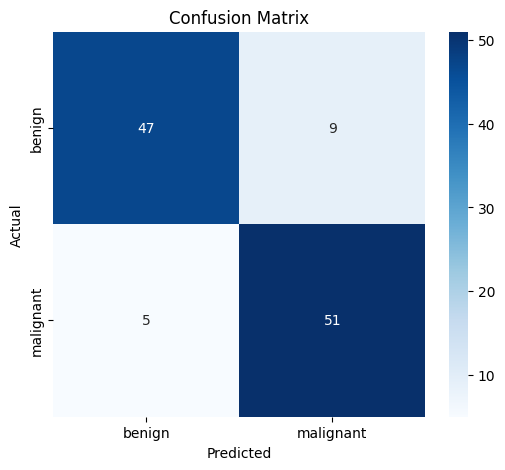

In [8]:
#Confusion Matrix
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


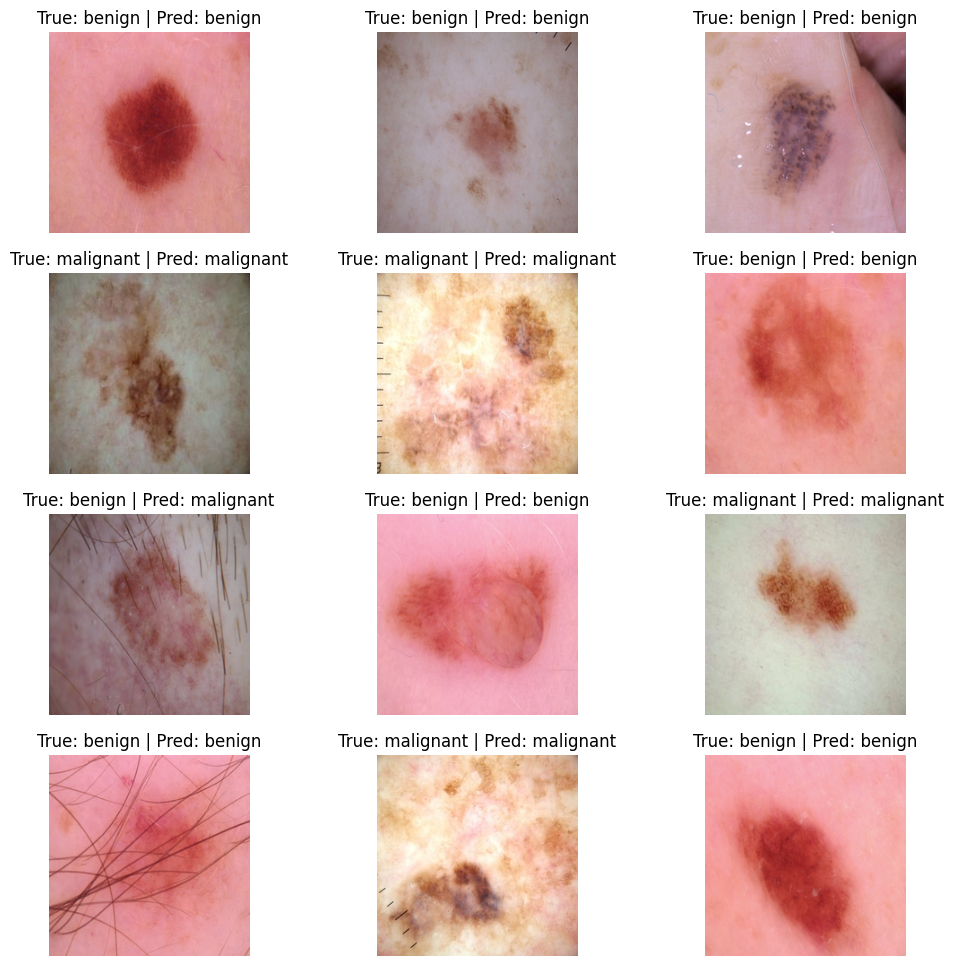

In [10]:
import random
from tensorflow.keras.preprocessing import image

# Choose 12 random images
indices = random.sample(range(len(val_data.filenames)), 12)

plt.figure(figsize=(12, 12))

for i, idx in enumerate(indices):
    img_path = val_data.filepaths[idx]

    # Load and preprocess exactly like the model expects
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array_expanded = np.expand_dims(img_array, axis=0)

    # Prediction
    pred_prob = model.predict(img_array_expanded, verbose=0)[0][0]
    pred_class = int(pred_prob > 0.5)

    true_class = true_classes[idx]

    plt.subplot(4, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"True: {class_labels[true_class]} | Pred: {class_labels[pred_class]}")
plt.show()


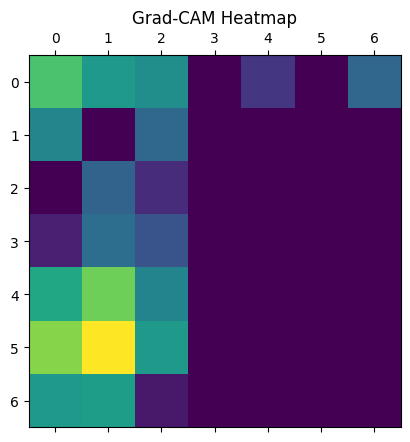

In [13]:
import numpy as np
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name="Conv_1"):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize manually, no .numpy()
    heatmap = np.maximum(heatmap, 0)
    if np.max(heatmap) != 0:
        heatmap = heatmap / np.max(heatmap)

    return heatmap


# ✔ Correct way to get 1 random image from generator
idx = random.randint(0, len(val_data) - 1)
x_batch, y_batch = val_data[idx]

img = x_batch[0]        # image
label = int(y_batch[0]) # label

img_array = np.expand_dims(img, axis=0)

heatmap = make_gradcam_heatmap(img_array, model)

plt.matshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.show()


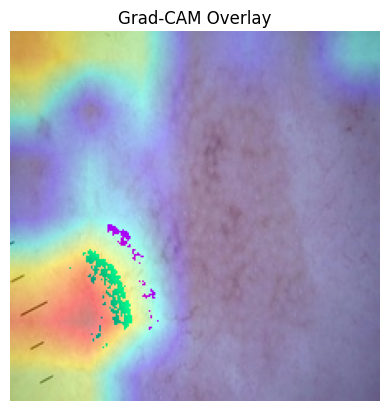

In [14]:
heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

superimposed = heatmap_color * 0.4 + img * 255

plt.imshow(np.uint8(superimposed))
plt.axis("off")
plt.title("Grad-CAM Overlay")
plt.show()
